In [5]:
import os
import random
import xml.etree.ElementTree as ET

import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd

In [6]:
# IMAGE EDA — CELL 2
# Locate images and annotation files automatically

ROOT = "gas_leak.v7i.voc"

image_extensions = (".jpg", ".jpeg", ".png")

image_paths = []
xml_paths = []

for root, dirs, files in os.walk(ROOT):
    for file in files:
        full_path = os.path.join(root, file)

        if file.lower().endswith(image_extensions):
            image_paths.append(full_path)

        if file.lower().endswith(".xml"):
            xml_paths.append(full_path)

print("Total Images Found:", len(image_paths))
print("Total Annotation Files Found:", len(xml_paths))

Total Images Found: 8881
Total Annotation Files Found: 8881


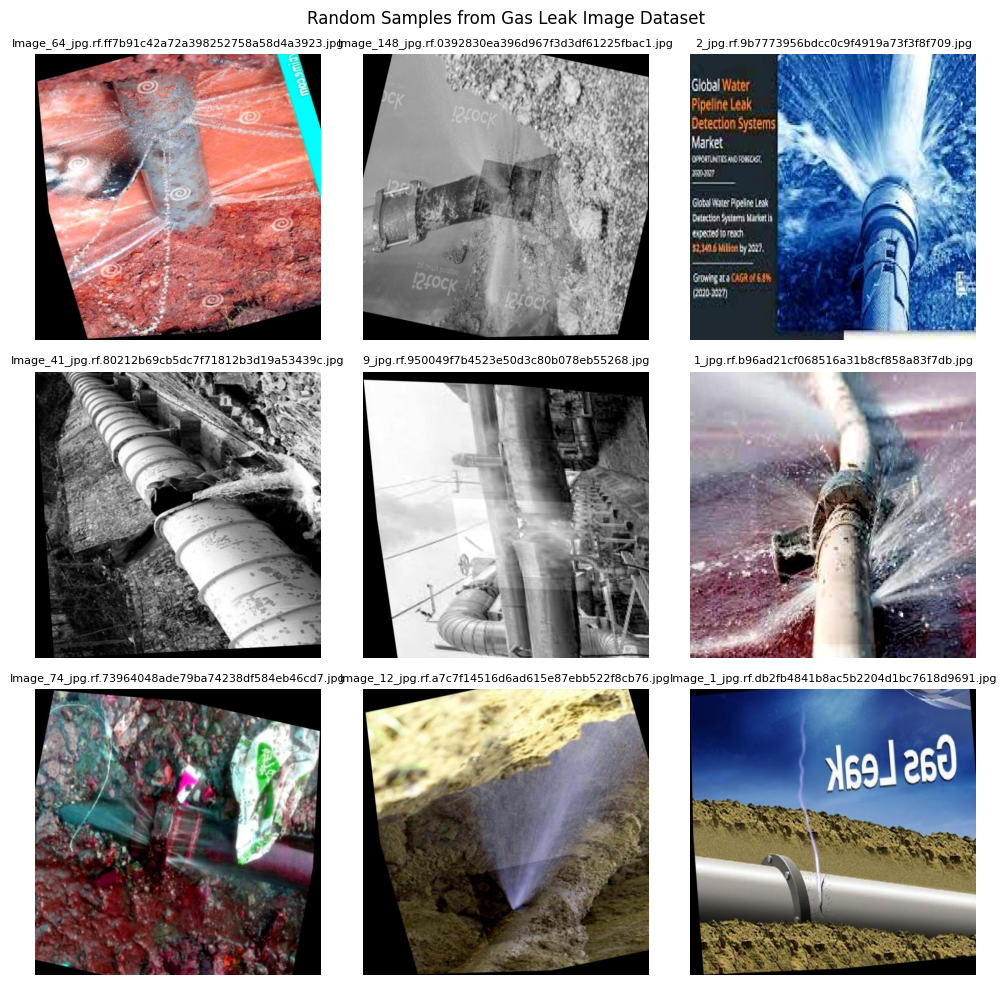

In [7]:
# IMAGE EDA — CELL 3
# Display a grid of random images

sample_n = 9  # change to 4 or 16 if you want
sample_n = min(sample_n, len(image_paths))

chosen = random.sample(image_paths, k=sample_n)

plt.figure(figsize=(10,10))
for i, p in enumerate(chosen, 1):
    img = Image.open(p).convert("RGB")
    plt.subplot(3, 3, i)
    plt.imshow(img)
    plt.title(os.path.basename(p), fontsize=8)
    plt.axis("off")

plt.suptitle("Random Samples from Gas Leak Image Dataset")
plt.tight_layout()
plt.show()

In [8]:
# IMAGE EDA — CELL 4
# Parse VOC XML annotations into a DataFrame

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.findtext("filename")
    size = root.find("size")
    w = int(size.findtext("width"))
    h = int(size.findtext("height"))

    rows = []
    for obj in root.findall("object"):
        cls = obj.findtext("name")
        bnd = obj.find("bndbox")
        xmin = int(float(bnd.findtext("xmin")))
        ymin = int(float(bnd.findtext("ymin")))
        xmax = int(float(bnd.findtext("xmax")))
        ymax = int(float(bnd.findtext("ymax")))
        rows.append([filename, cls, xmin, ymin, xmax, ymax, w, h])

    return rows

bbox_rows = []
for x in xml_paths:
    bbox_rows.extend(parse_voc_xml(x))

bbox_df = pd.DataFrame(
    bbox_rows,
    columns=["filename", "class", "xmin", "ymin", "xmax", "ymax", "img_w", "img_h"]
)

print("Total Bounding Boxes:", len(bbox_df))
bbox_df.head()

Total Bounding Boxes: 9384


,filename,class,xmin,ymin,xmax,ymax,img_w,img_h
0,10_jpg.rf.008e8816560a6d095b4467ffbe2d8b5c.jpg,leak,239,327,451,488,600,600
1,10_jpg.rf.01471de9727645a87d48ba3f8d6032ff.jpg,leak,138,46,421,479,600,600
2,10_jpg.rf.0151ca9aceeb119ad81333e7af1148fd.jpg,leak,81,140,457,446,600,600
3,10_jpg.rf.03e8c877ac8894064bee4f5d20377023.jpg,leak,252,274,378,387,600,398
4,10_jpg.rf.0541bf524bc0bb6c09f7dc788f1406ad.jpg,leak,143,79,425,465,600,600


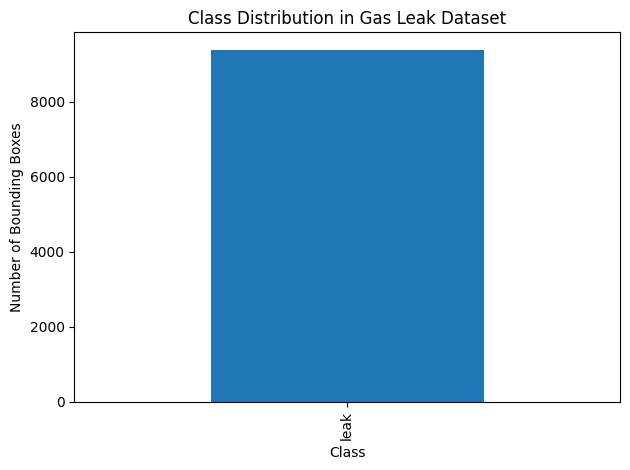

In [9]:
# IMAGE EDA — CELL 5
# Class distribution (how many instances per label)

class_counts = bbox_df["class"].value_counts()

plt.figure()
class_counts.plot(kind="bar")
plt.title("Class Distribution in Gas Leak Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Bounding Boxes")
plt.tight_layout()
plt.show()

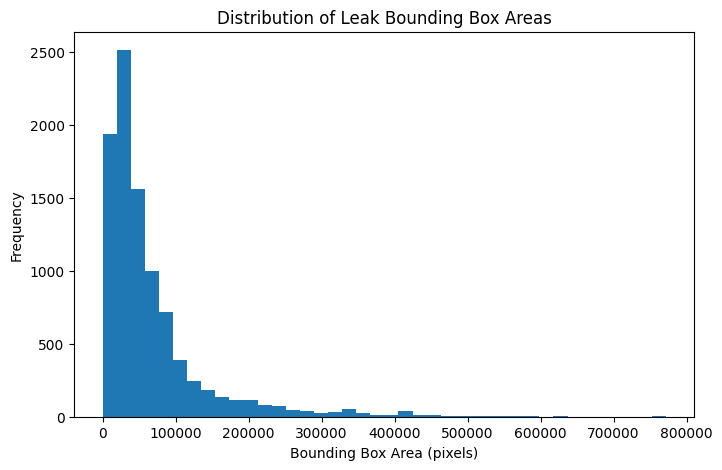

In [10]:
# IMAGE EDA — CELL 6
# Calculate bounding box sizes

bbox_df["box_width"] = bbox_df["xmax"] - bbox_df["xmin"]
bbox_df["box_height"] = bbox_df["ymax"] - bbox_df["ymin"]
bbox_df["box_area"] = bbox_df["box_width"] * bbox_df["box_height"]

plt.figure(figsize=(8,5))
plt.hist(bbox_df["box_area"], bins=40)

plt.title("Distribution of Leak Bounding Box Areas")
plt.xlabel("Bounding Box Area (pixels)")
plt.ylabel("Frequency")

plt.show()

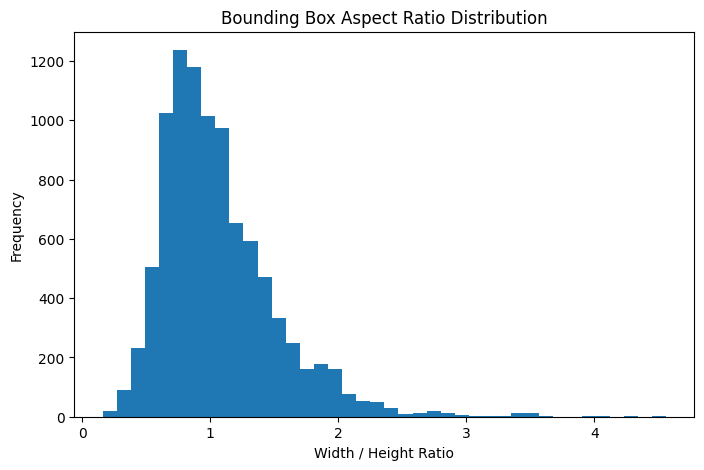

In [11]:
# IMAGE EDA — CELL 7
# Bounding box aspect ratio (width / height)

bbox_df["aspect_ratio"] = bbox_df["box_width"] / (bbox_df["box_height"] + 1e-6)

plt.figure(figsize=(8,5))
plt.hist(bbox_df["aspect_ratio"], bins=40)

plt.title("Bounding Box Aspect Ratio Distribution")
plt.xlabel("Width / Height Ratio")
plt.ylabel("Frequency")

plt.show()

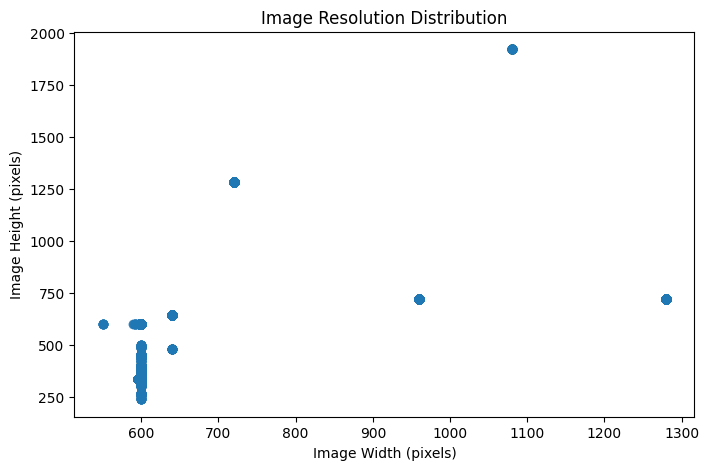

In [12]:
# IMAGE EDA — CELL 8
# Image resolution analysis

image_meta = bbox_df[["filename", "img_w", "img_h"]].drop_duplicates()

plt.figure(figsize=(8,5))
plt.scatter(image_meta["img_w"], image_meta["img_h"], alpha=0.6)

plt.title("Image Resolution Distribution")
plt.xlabel("Image Width (pixels)")
plt.ylabel("Image Height (pixels)")

plt.show()

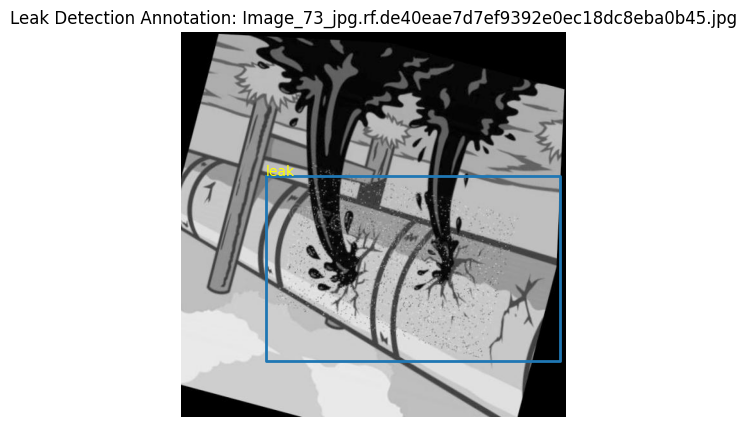

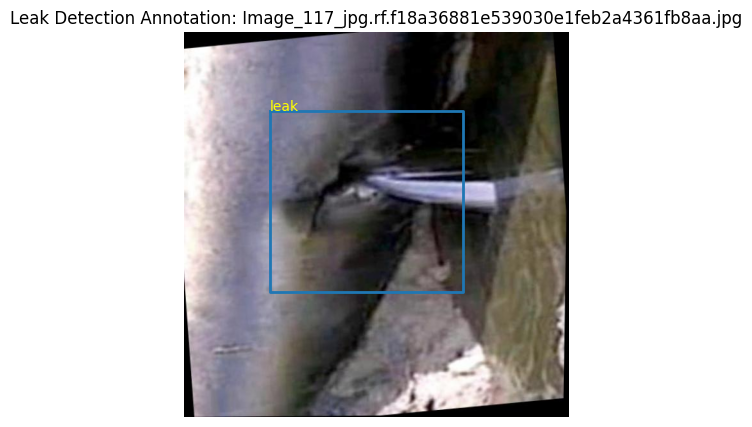

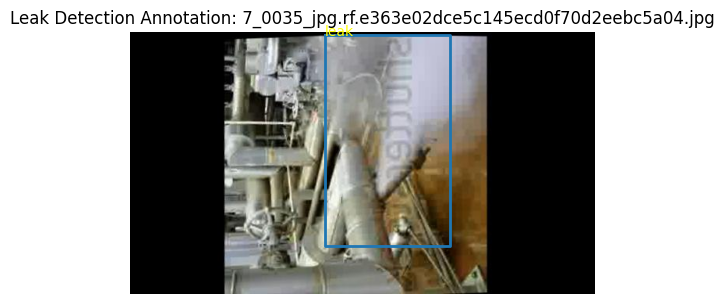

In [13]:
# IMAGE EDA — CELL 9
# Show images with bounding boxes drawn

def find_image_path(filename):
    for p in image_paths:
        if os.path.basename(p) == filename:
            return p
    return None

# pick 3 random annotated images
sample_files = bbox_df["filename"].drop_duplicates().sample(3, random_state=42)

for fname in sample_files:
    img_path = find_image_path(fname)
    if img_path is None:
        continue

    img = Image.open(img_path).convert("RGB")

    plt.figure(figsize=(6,5))
    plt.imshow(img)

    # draw bounding boxes
    rows = bbox_df[bbox_df["filename"] == fname]
    for _, r in rows.iterrows():
        xmin, ymin, xmax, ymax = r["xmin"], r["ymin"], r["xmax"], r["ymax"]

        plt.plot(
            [xmin, xmax, xmax, xmin, xmin],
            [ymin, ymin, ymax, ymax, ymin],
            linewidth=2
        )

        plt.text(xmin, ymin, r["class"], color="yellow", fontsize=10)

    plt.title(f"Leak Detection Annotation: {fname}")
    plt.axis("off")
    plt.show()